In [1]:
from dotenv import load_dotenv
import os
import sqlalchemy as sa
import pandas as pd
load_dotenv(override=True)

True

In [2]:
pd.__version__

'2.3.3'

In [3]:
# Connect to Supabase.
supabase = sa.create_engine(os.getenv("SUPABASE_CONNECTION_STRING"))

# Simplify data loading.
def load_data(sql):
    query = sa.text(sql)
    return pd.read_sql(query, supabase)

In [4]:
# Load all rows from sales table. Not recommended in production.
df = load_data("SELECT * FROM sales ORDER BY id ASC")

In [5]:
# 5 first rows from previously loaded dataframe.
df.head()

,id,sale_id,invoice_id,sale_date,customer_id,product_id,quantity,unit_price,total_price,channel,store_location,payment_method
0,1,1,INV-202301-00001,2023-01-10,2588.0,1274,2,234.79,469.58,pood,Tallinn,kaart
1,2,2,INV-202301-00002,2023-01-16,4338.0,1207,2,241.13,482.26,pood,Pärnu,järelmaks
2,3,3,INV-202301-00003,2023-01-05,4673.0,1264,1,258.46,221.19,pood,Pärnu,järelmaks
3,4,4,INV-202301-00004,2023-01-02,4677.0,1341,3,45.21,135.63,pood,Tartu,sularaha
4,5,5,INV-202301-00005,2023-01-13,2390.0,1284,1,99.57,99.57,pood,Tartu,kaart


In [6]:
# Print a concise summary of a DataFrame.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10118 entries, 0 to 10117
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              10118 non-null  int64         
 1   sale_id         10118 non-null  int64         
 2   invoice_id      10118 non-null  object        
 3   sale_date       10118 non-null  datetime64[ns]
 4   customer_id     9130 non-null   float64       
 5   product_id      10118 non-null  int64         
 6   quantity        10118 non-null  int64         
 7   unit_price      10118 non-null  float64       
 8   total_price     10118 non-null  float64       
 9   channel         10118 non-null  object        
 10  store_location  6656 non-null   object        
 11  payment_method  10118 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(4), object(4)
memory usage: 948.7+ KB


In [7]:
df["sale_date"]

0       2023-01-10
1       2023-01-16
2       2023-01-05
3       2023-01-02
4       2023-01-13
           ...    
10113   2025-02-26
10114   2025-02-11
10115   2025-02-18
10116   2025-02-22
10117   2025-02-27
Name: sale_date, Length: 10118, dtype: datetime64[ns]

In [8]:
df["sale_date"] = pd.to_datetime(df["sale_date"])
df["sale_date"]

0       2023-01-10
1       2023-01-16
2       2023-01-05
3       2023-01-02
4       2023-01-13
           ...    
10113   2025-02-26
10114   2025-02-11
10115   2025-02-18
10116   2025-02-22
10117   2025-02-27
Name: sale_date, Length: 10118, dtype: datetime64[ns]

In [9]:
# SELECT sale_date, sum(total_price) FROM sales GROUP BY sale_date ORDER BY sale_date ASC;
daily_sales = df.groupby("sale_date")["total_price"].sum().reset_index()
daily_sales

,sale_date,total_price
0,2023-01-01,3424.32
1,2023-01-02,3226.10
2,2023-01-03,1440.98
3,2023-01-04,2721.23
4,2023-01-05,3274.37
...,...,...
813,2026-06-04,420.36
814,2026-06-09,280.13
815,2026-06-15,-128.44
816,2026-06-27,583.44


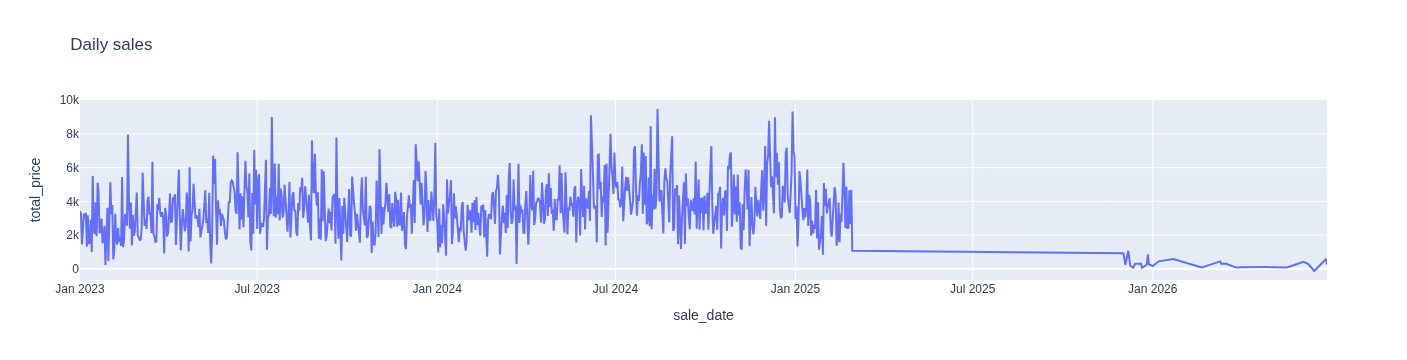

In [10]:
import plotly.express as px
fig = px.line(daily_sales, x="sale_date", y="total_price", title="Daily sales")
fig.show()

In [11]:
sales_df = df
sales_df

,id,sale_id,invoice_id,sale_date,customer_id,product_id,quantity,unit_price,total_price,channel,store_location,payment_method
0,1,1,INV-202301-00001,2023-01-10,2588.0,1274,2,234.79,469.58,pood,Tallinn,kaart
1,2,2,INV-202301-00002,2023-01-16,4338.0,1207,2,241.13,482.26,pood,Pärnu,järelmaks
2,3,3,INV-202301-00003,2023-01-05,4673.0,1264,1,258.46,221.19,pood,Pärnu,järelmaks
3,4,4,INV-202301-00004,2023-01-02,4677.0,1341,3,45.21,135.63,pood,Tartu,sularaha
4,5,5,INV-202301-00005,2023-01-13,2390.0,1284,1,99.57,99.57,pood,Tartu,kaart
...,...,...,...,...,...,...,...,...,...,...,...,...
10113,10114,10114,INV-202502-00344,2025-02-26,3878.0,1275,1,62.82,62.82,pood,Tallinn,kaart
10114,10115,10115,INV-202502-00345,2025-02-11,3991.0,1114,1,74.70,-74.70,pood,Tartu,järelmaks
10115,10116,10116,INV-202502-00346,2025-02-18,2133.0,1003,1,52.04,52.04,online,None,järelmaks
10116,10117,10117,INV-202502-00347,2025-02-22,2908.0,1278,1,263.13,263.13,online,None,järelmaks


In [12]:
products_df = load_data("SELECT * FROM products ORDER BY product_id ASC")
products_df

,product_id,product_name,category,subcategory,supplier,cost_price,retail_price,eco_certified,created_at
0,1001,Praktiline seemisnahkne tennised,jalanõusid,tossud,Soome Tehdas OY,99.21,157.49,False,2022-05-12
1,1002,Mugav linane linane kostüüm,meeste_riided,ülikonnad,Riia Stils SIA,173.56,274.78,True,2022-05-10
2,1003,Elegantne orgaaniline kleit,laste_riided,kleidid,Rakvere Tekstiil OÜ,31.83,52.04,False,2020-02-19
3,1004,Minimalistlik puuvillane tuunika,naiste_riided,pluusid,Vilma Design OÜ,29.41,41.63,False,2022-12-26
4,1005,Mugav tweed kardigan,meeste_riided,kampsunid,Nordic Fashion Group OÜ,135.70,198.29,True,2021-06-19
...,...,...,...,...,...,...,...,...,...
357,1358,Luksuslik keraamiline elastne vöö,aksessuaarid,vööd,Pärnu Kudumid OÜ,99.50,149.55,False,2022-07-17
358,1359,Moodne keraamiline sall,aksessuaarid,sallid,Saare Käsitöö OÜ,91.71,147.16,False,2024-07-09
359,1360,Stiilne orgaaniline pidžaama,laste_riided,komplektid,Eesti Nahk AS,71.74,106.82,True,2022-09-05
360,1361,Klassikaline kashmiir pusa,naiste_riided,pusad,Balti Mood OÜ,160.82,225.81,False,2022-06-03


In [13]:
"""
SELECT
    *
FROM sales s
INNER JOIN products p ON s.product_id = p.product_id
ORDER BY s.id ASC;
"""
merged_df = sales_df.merge(products_df, left_on='product_id', right_on='product_id', suffixes=('_sale', '_product'))
merged_df

,id,sale_id,invoice_id,sale_date,customer_id,product_id,quantity,unit_price,total_price,channel,store_location,payment_method,product_name,category,subcategory,supplier,cost_price,retail_price,eco_certified,created_at
0,1,1,INV-202301-00001,2023-01-10,2588.0,1274,2,234.79,469.58,pood,Tallinn,kaart,Soe teksane chino püksid,meeste_riided,püksid,Tartu Tekstiil AS,156.71,234.79,False,2024-09-13
1,2,2,INV-202301-00002,2023-01-16,4338.0,1207,2,241.13,482.26,pood,Pärnu,järelmaks,Õhuline seemisnahkne rannasandaalid,jalanõusid,sandaalid,Türgi Tekstil A.Ş.,170.10,241.13,True,2021-10-18
2,3,3,INV-202301-00003,2023-01-05,4673.0,1264,1,258.46,221.19,pood,Pärnu,järelmaks,Mugav goretex platvormi kontsad,jalanõusid,kontsad,Itaalia Moda SRL,141.90,221.19,False,2024-11-21
3,4,4,INV-202301-00004,2023-01-02,4677.0,1341,3,45.21,135.63,pood,Tartu,sularaha,Stiilne siidine labakindad,aksessuaarid,kindad,Leedu Linane UAB,27.64,45.21,False,2020-07-06
4,5,5,INV-202301-00005,2023-01-13,2390.0,1284,1,99.57,99.57,pood,Tartu,kaart,Vintage softshell alussärk,laste_riided,trikotaaž,Vilma Design OÜ,59.84,99.57,True,2022-11-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10113,10114,10114,INV-202502-00344,2025-02-26,3878.0,1275,1,62.82,62.82,pood,Tallinn,kaart,Trendikas villane dressikomplekt,laste_riided,komplektid,Riia Stils SIA,38.30,62.82,False,2022-06-11
10114,10115,10115,INV-202502-00345,2025-02-11,3991.0,1114,1,74.70,-74.70,pood,Tartu,järelmaks,Luksuslik villane saapad,jalanõusid,botased,Tartu Tekstiil AS,52.97,74.70,True,2021-03-19
10115,10116,10116,INV-202502-00346,2025-02-18,2133.0,1003,1,52.04,52.04,online,None,järelmaks,Elegantne orgaaniline kleit,laste_riided,kleidid,Rakvere Tekstiil OÜ,31.83,52.04,False,2020-02-19
10116,10117,10117,INV-202502-00347,2025-02-22,2908.0,1278,1,263.13,263.13,online,None,järelmaks,Soe satiinne pluus,naiste_riided,pluusid,Vilma Design OÜ,174.86,263.13,False,2023-06-10
